In [71]:

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix
import pandas as pd
from torch import nn
from torch.utils.data import random_split
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
from seaborn import heatmap
import numpy as np
import PIL
import torch.nn.functional as F




label_map = {
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'E',
    6: 'F',
    7: 'G',
    8: 'H',
    9: 'I',
    10: 'J',
    11: 'K',
    12: 'L',
    13: 'M',
    14: 'N',
    15: 'O',
    16: 'P',
    17: 'Q',
    18: 'R',
    19: 'S',
    20: 'T',
    21: 'U',
    22: 'V',
    23: 'W',
    24: 'X',
    25: 'Y',
    26: 'Z'
}
BATCH_SIZE = 64
NUM_EPOCHS = 10
NUM_CLASSES = 26
NUM_WORKERS = 0

# EDA

In [72]:
# определяем преобразования для изображений
transform = transforms.Compose([
 transforms.ToTensor(), # PIL →тензор, значения [0, 1]
 transforms.Lambda(lambda x: x.view(-1))
])

# загрузка обучающей выборки
full_train = datasets.EMNIST(
 root='./data', # папка для сохранения данных
 split='letters', # буквенный датасет (не digitsили balanced)
 train=True, # обучающая выборка
 download=True, # скачать, если нет локально
 transform=transform # применяем преобразования
)
# загрузка тестовой выборки
test_dataset = datasets.EMNIST(
 root='./data',
 split='letters',
 train=False, # тестовая выборка
 download=True,
 transform=transform
)
print(f"Размер полной обучающей выборки: {len(full_train)}")
print(f"Размер оригинальной тестовой выборки:{len(test_dataset)}")

Размер полной обучающей выборки: 124800
Размер оригинальной тестовой выборки:20800


In [73]:
# получение данных из PyTorch
X_train = full_train.data.numpy().reshape(-1,784).astype('float32') / 255.0
y_train = full_train.targets.numpy().astype('int32') - 1
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)
X_test = test_dataset.data.numpy().reshape(-1,784).astype('float32') / 255.0
y_test = test_dataset.targets.numpy().astype('int32') - 1
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:{X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
# создание tf.data.Dataset
train_dataset_tf = tf.data.Dataset.from_tensor_slices((X_train,y_train))
train_dataset_tf = train_dataset_tf.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val,y_val))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset_tf = tf.data.Dataset.from_tensor_slices((X_test,y_test))
test_dataset_tf = test_dataset_tf.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

X_train: (112320, 784), y_train: (112320,)
X_val:(12480, 784), y_val: (12480,)
X_test: (20800, 784), y_test: (20800,)


In [74]:
full_train[0][0].reshape(28,28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0039, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0784, 0.4471, 0.4902, 0.3216, 0.1451, 0.1451, 0.1529,
         0.4510, 0.6157, 0.3686, 0.0824, 0.0392, 0.1255, 0.1451, 0.1451, 0.1451,
         0.1451, 0.1451, 0.1451, 0.1451, 0.3216, 0.4902

Text(0.5, 1.0, 'Label: W')

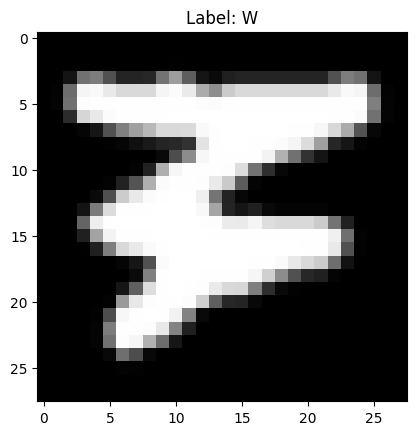

In [75]:
plt.imshow(full_train[0][0].reshape(28,28), cmap='grey')
plt.title('Label: '+label_map[full_train[0][1]])

In [76]:
print('Размер одного изображения в пикселях: ', list(full_train[4][0].reshape(28,28).size()))

Размер одного изображения в пикселях:  [28, 28]


In [77]:
print('Диапазон значения пикселей: от '+str(int(full_train.data.min()))+' до '+str(int(full_train.data.max())))

Диапазон значения пикселей: от 0 до 255


<BarContainer object of 26 artists>

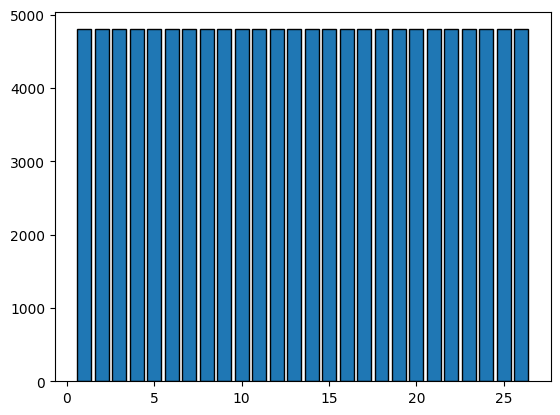

In [78]:
df_classes = pd.DataFrame({
    'targets': full_train.targets.numpy(),
    'count': [1]*len(full_train.targets.numpy())
    })

df_count = df_classes.groupby('targets').count()

plt.bar(df_count.index, df_count['count'].values, edgecolor='black')

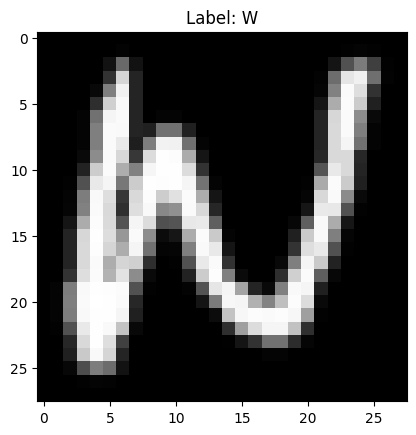

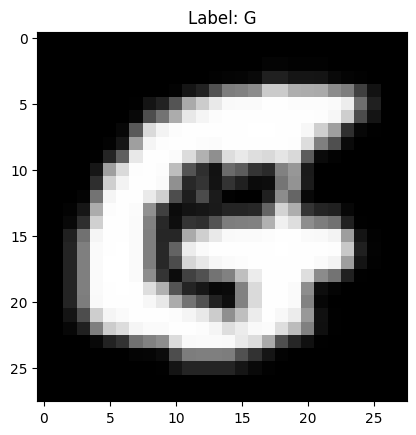

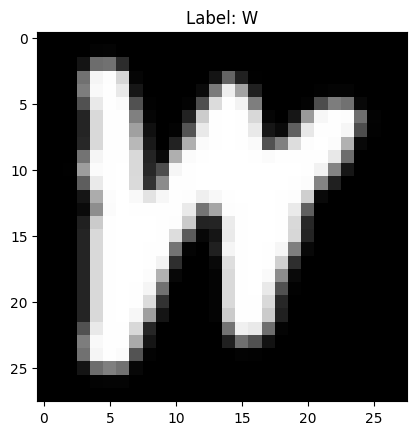

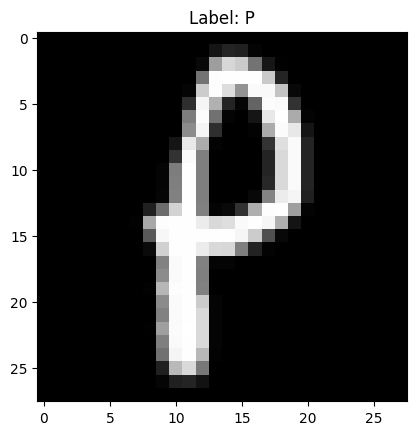

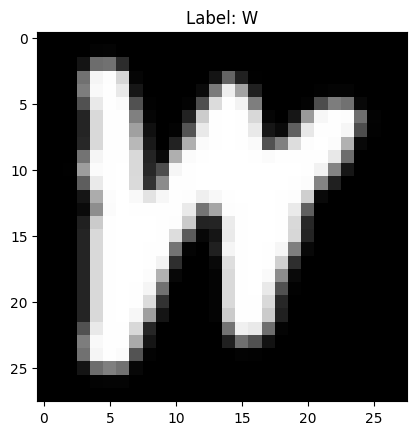

In [79]:
import matplotlib.pyplot as plt
import random

for i in range(5):
    a = random.randint(0, 5)
    plt.imshow(full_train[a][0].reshape(28,28).T, cmap='grey')
    plt.title('Label: '+label_map[full_train[a][1]])
    plt.show()

In [80]:
full_train[2][0].max()
full_train[2][0].min()

tensor(0.)

In [81]:
generator = torch.Generator().manual_seed(42)
df_train, df_val = random_split(full_train, [0.9, 0.1], generator=generator)

train_loader = DataLoader(
    df_train,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    df_val,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

# Модель PyTorch

In [82]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 26),
        )
    
    def forward(self, x):
        return self.model(x)

In [83]:
def train_epoch(model, train_loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    for X_batch, y_batch in train_loader:
        y_batch = y_batch - 1 
        
        optimizer.zero_grad()
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == y_batch).sum().item()
    return total_loss / len(train_loader), correct / len(train_loader.dataset)


def validate(model, val_loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_batch = y_batch - 1 
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == y_batch).sum().item()
    return total_loss / len(val_loader), correct / len(val_loader.dataset)

def train(model, train_loader, val_loader, criterion, optimizer, epochs):
    train_loss_arr = []
    val_loss_arr = []
    val_acc_arr = []
    train_acc_arr = []
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = validate(model, val_loader, criterion)
        # Array for plot
        train_loss_arr.append(train_loss)
        val_loss_arr.append(val_loss)
        val_acc_arr.append(val_acc)
        train_acc_arr.append(train_acc)
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Acc: ', 
              f'{train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    return train_loss_arr, train_acc_arr, val_loss_arr, val_acc_arr
        
def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_batch = y_batch - 1 
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    print(f'Test Acc: {correct / total:.4f}')
    
    
def predict(model, X):
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        _, predicted = torch.max(outputs.data, 1)
    return predicted


def predict_val(model, test_loader):
    model.eval()
    all_predictions = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            all_predictions.append(predicted)
    return torch.cat(all_predictions)

In [84]:
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

train_loss, train_acc, val_loss, val_acc = train(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS)

Epoch 1/10, Train Loss: 0.8608, Train Acc:  0.7458, Val Loss: 0.6777, Val Acc: 0.8016
Epoch 2/10, Train Loss: 0.6412, Train Acc:  0.8173, Val Loss: 0.5930, Val Acc: 0.8356
Epoch 3/10, Train Loss: 0.6107, Train Acc:  0.8304, Val Loss: 0.6576, Val Acc: 0.8250
Epoch 4/10, Train Loss: 0.5832, Train Acc:  0.8410, Val Loss: 0.6041, Val Acc: 0.8373
Epoch 5/10, Train Loss: 0.5488, Train Acc:  0.8521, Val Loss: 0.5862, Val Acc: 0.8476
Epoch 6/10, Train Loss: 0.5417, Train Acc:  0.8553, Val Loss: 0.5468, Val Acc: 0.8634
Epoch 7/10, Train Loss: 0.5311, Train Acc:  0.8606, Val Loss: 0.5955, Val Acc: 0.8567
Epoch 8/10, Train Loss: 0.5157, Train Acc:  0.8642, Val Loss: 0.5982, Val Acc: 0.8526
Epoch 9/10, Train Loss: 0.5131, Train Acc:  0.8653, Val Loss: 0.5682, Val Acc: 0.8646
Epoch 10/10, Train Loss: 0.5050, Train Acc:  0.8669, Val Loss: 0.6371, Val Acc: 0.8486


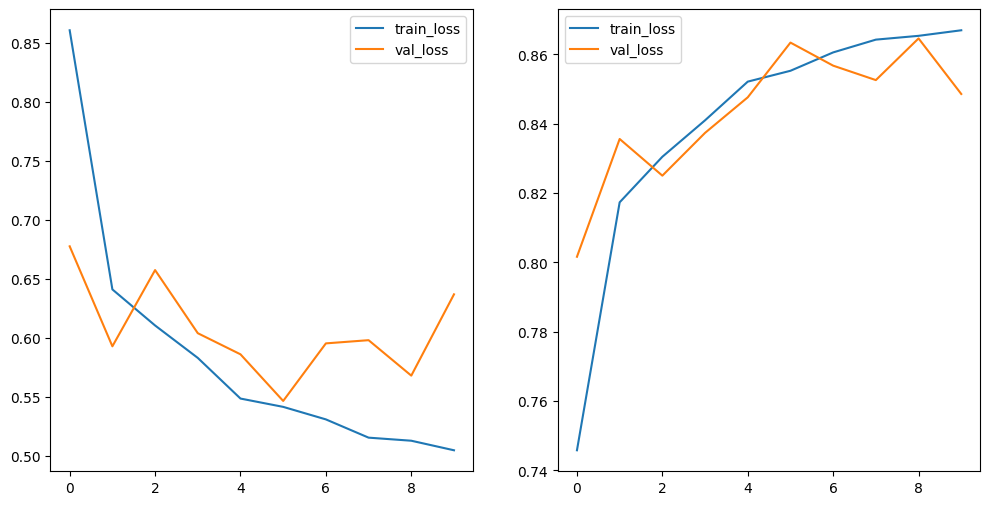

In [85]:
fig = plt.figure(figsize=(12, 6))
ax1, ax2 = fig.subplots(1, 2)
ax1.plot(range(len(train_loss)), train_loss, label='train_loss')
ax1.plot(range(len(val_loss)), val_loss, label='val_loss')
ax1.legend()
ax2.plot(range(len(train_acc)), train_acc, label='train_loss')
ax2.plot(range(len(val_acc)), val_acc, label='val_loss')
ax2.legend()

In [86]:
joblib.dump(train_loss, './letter_obj/torch_mlp_train_loss.joblib')
joblib.dump(train_acc, './letter_obj/torch_mlp_train_acc.joblib')
joblib.dump(val_loss, './letter_obj/torch_mlp_val_loss.joblib')
joblib.dump(val_acc, './letter_obj/torch_mlp_val_acc.joblib')
torch.save(model, './models/MLP.pth')

In [87]:
class MLP_dropout(nn.Module):
    def __init__(self):
        super(MLP_dropout, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 26),
        )
    
    def forward(self, x):
        return self.model(x)

In [88]:
model_dropout = MLP_dropout()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_dropout.parameters(), lr=0.01)

train_loss_dropout, train_acc_dropout, val_loss_dropout, val_acc_dropout = train(model_dropout, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS)

Epoch 1/10, Train Loss: 1.7435, Train Acc:  0.5046, Val Loss: 1.1046, Val Acc: 0.6522
Epoch 2/10, Train Loss: 1.5749, Train Acc:  0.5668, Val Loss: 1.0110, Val Acc: 0.7139
Epoch 3/10, Train Loss: 1.5277, Train Acc:  0.5851, Val Loss: 1.0013, Val Acc: 0.7216
Epoch 4/10, Train Loss: 1.4956, Train Acc:  0.5940, Val Loss: 0.9843, Val Acc: 0.7098
Epoch 5/10, Train Loss: 1.4866, Train Acc:  0.6006, Val Loss: 0.9819, Val Acc: 0.7377
Epoch 6/10, Train Loss: 1.4935, Train Acc:  0.5988, Val Loss: 0.9395, Val Acc: 0.7409
Epoch 7/10, Train Loss: 1.4820, Train Acc:  0.5988, Val Loss: 0.9222, Val Acc: 0.7504
Epoch 8/10, Train Loss: 1.4869, Train Acc:  0.6015, Val Loss: 0.9783, Val Acc: 0.7249
Epoch 9/10, Train Loss: 1.4792, Train Acc:  0.6019, Val Loss: 1.0073, Val Acc: 0.7222
Epoch 10/10, Train Loss: 1.5107, Train Acc:  0.5963, Val Loss: 0.9879, Val Acc: 0.7326


In [89]:
joblib.dump(train_loss_dropout, './letter_obj/torch_mlp_train_loss_dropout.joblib')
joblib.dump(train_acc_dropout, './letter_obj/torch_mlp_train_acc_dropout.joblib')
joblib.dump(val_loss_dropout, './letter_obj/torch_mlp_val_loss_dropout.joblib')
joblib.dump(val_acc_dropout, './letter_obj/torch_mlp_val_acc_dropout.joblib')
torch.save(model_dropout, './models/MLP_dropout.pth')

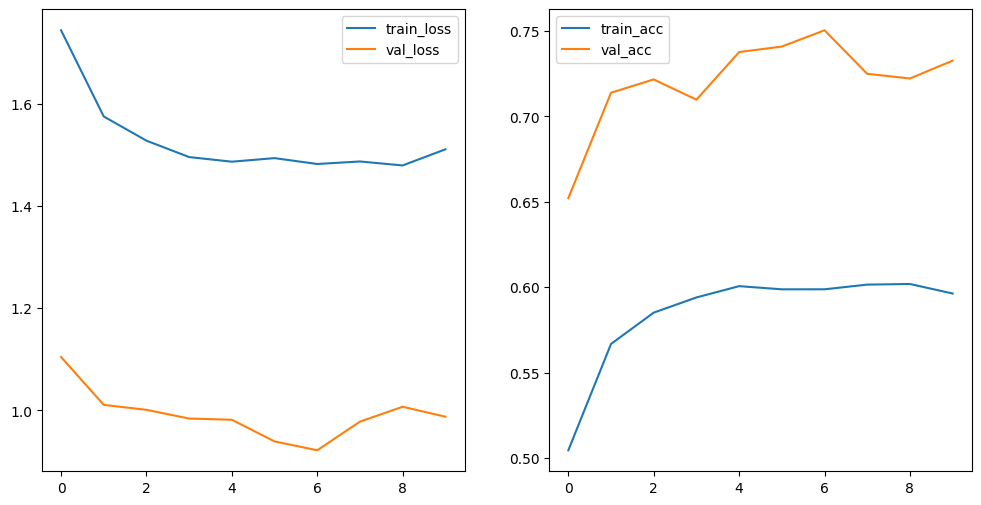

In [90]:
fig = plt.figure(figsize=(12, 6))
ax1, ax2 = fig.subplots(1, 2)
ax1.plot(range(len(train_loss_dropout)), train_loss_dropout, label='train_loss')
ax1.plot(range(len(val_loss_dropout)), val_loss_dropout, label='val_loss')
ax1.legend()
ax2.plot(range(len(train_acc_dropout)), train_acc_dropout, label='train_acc')
ax2.plot(range(len(val_acc_dropout)), val_acc_dropout, label='val_acc')
ax2.legend()

# Модель TF

In [ ]:
import tensorflow as tf

class MLP_tf(tf.keras.Model):
    def __init__(self):
        super(MLP_tf, self).__init__()
        self.model = models.Sequential([
            layers.Dense(512, activation='relu', input_shape=(784,)),
            layers.Dense(256, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(26) # Выходной слой обы.чно без активации (для CrossEntropyLoss)
        ])

    def call(self, x):
        return self.model(x)

model_tf = MLP_tf()
model_tf.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                 loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                 metrics=['accuracy'])

c:\Users\raven\Projects\tutor\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [92]:
model_tf.fit(train_dataset_tf, 
          validation_data=val_dataset, 
          epochs=NUM_EPOCHS)

Epoch 1/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7482 - loss: 0.8422 - val_accuracy: 0.8163 - val_loss: 0.6362
Epoch 2/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8205 - loss: 0.6193 - val_accuracy: 0.8322 - val_loss: 0.5843
Epoch 3/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8386 - loss: 0.5746 - val_accuracy: 0.8458 - val_loss: 0.5463
Epoch 4/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8508 - loss: 0.5401 - val_accuracy: 0.8562 - val_loss: 0.5471
Epoch 5/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8554 - loss: 0.5236 - val_accuracy: 0.8482 - val_loss: 0.5608
Epoch 6/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8580 - loss: 0.5183 - val_accuracy: 0.8547 - val_loss: 0.5695
Epoch 7/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8628 - loss: 0.5070 - val_accuracy: 0.8454 - val_loss: 0.5857
Epoch 8/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8638 - loss: 0.5064 - 

In [93]:
train_loss_tf = model_tf.history.history['loss']
train_acc_tf = model_tf.history.history['accuracy']
val_loss_tf = model_tf.history.history['val_loss']
val_acc_tf = model_tf.history.history['val_accuracy']

In [94]:
joblib.dump(train_loss_tf, './letter_obj/tf_mlp_train_loss.joblib')
joblib.dump(train_acc_tf, './letter_obj/tf_mlp_train_acc.joblib')
joblib.dump(val_loss_tf, './letter_obj/tf_mlp_val_loss.joblib')
joblib.dump(val_acc_tf, './letter_obj/tf_mlp_val_acc.joblib')
model_tf.save('./models/MLP_tf.keras')

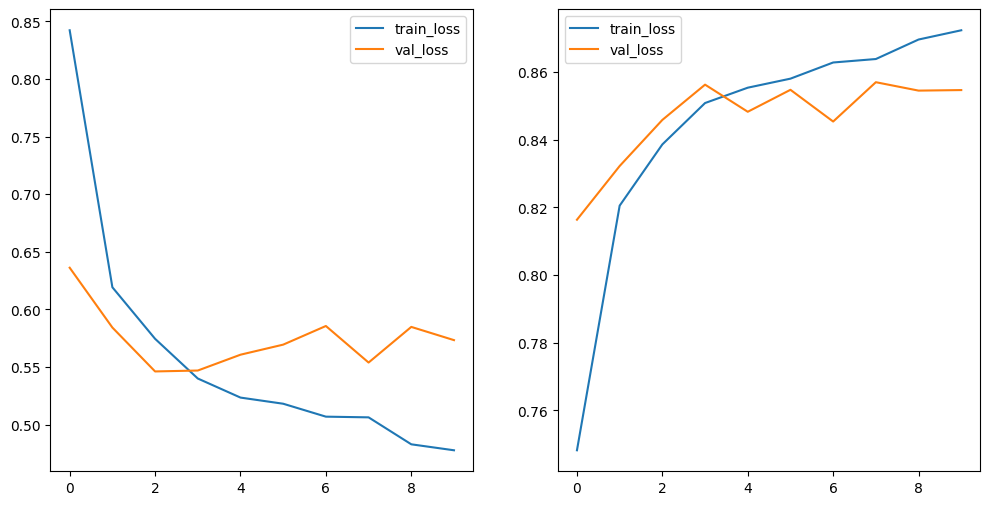

In [95]:
fig = plt.figure(figsize=(12, 6))
ax1, ax2 = fig.subplots(1, 2)
ax1.plot(range(len(train_loss_tf)), train_loss_tf, label='train_loss')
ax1.plot(range(len(val_loss_tf)), val_loss_tf, label='val_loss')
ax1.legend()
ax2.plot(range(len(train_acc_tf)), train_acc_tf, label='train_loss')
ax2.plot(range(len(val_acc_tf)), val_acc_tf, label='val_loss')
ax2.legend()

In [99]:
class MLP_tf_dropout(tf.keras.Model):
    def __init__(self):
        super(MLP_tf_dropout, self).__init__()
        self.model = models.Sequential([
            layers.Dense(512, activation='relu', input_shape=(784,)),
            layers.Dropout(0.3),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(26) # Выходной слой обычно без активации (для CrossEntropyLoss)
        ])

    def call(self, x):
        return self.model(x)

model_tf_dropout = MLP_tf_dropout()
model_tf_dropout.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                 loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                 metrics=['accuracy'])

In [100]:
model_tf_dropout.fit(train_dataset_tf, 
          validation_data=val_dataset, 
          epochs=NUM_EPOCHS)

Epoch 1/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7534 - loss: 0.8372 - val_accuracy: 0.8200 - val_loss: 0.6190
Epoch 2/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8198 - loss: 0.6356 - val_accuracy: 0.8323 - val_loss: 0.6030
Epoch 3/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8370 - loss: 0.5888 - val_accuracy: 0.8421 - val_loss: 0.5906
Epoch 4/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8449 - loss: 0.5660 - val_accuracy: 0.8538 - val_loss: 0.5581
Epoch 5/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8533 - loss: 0.5479 - val_accuracy: 0.8551 - val_loss: 0.5608
Epoch 6/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8581 - loss: 0.5268 - val_accuracy: 0.8485 - val_loss: 0.5608
Epoch 7/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8589 - loss: 0.5267 - val_accuracy: 0.8411 - val_loss: 0.6076
Epoch 8/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8670 - loss: 0.4994 - 

In [101]:
train_loss_tf_dropout = model_tf_dropout.history.history['loss']
train_acc_tf_dropout = model_tf_dropout.history.history['accuracy']
val_loss_tf_dropout = model_tf_dropout.history.history['val_loss']
val_acc_tf_dropout = model_tf_dropout.history.history['val_accuracy']

In [102]:
joblib.dump(train_loss_tf_dropout, './letter_obj/tf_mlp_train_loss_dropout.joblib')
joblib.dump(train_acc_tf_dropout, './letter_obj/tf_mlp_train_acc_dropout.joblib')
joblib.dump(val_loss_tf_dropout, './letter_obj/tf_mlp_val_loss_dropout.joblib')
joblib.dump(val_acc_tf_dropout, './letter_obj/tf_mlp_val_acc_dropout.joblib')
model_tf_dropout.save('./models/MLP_tf.keras')

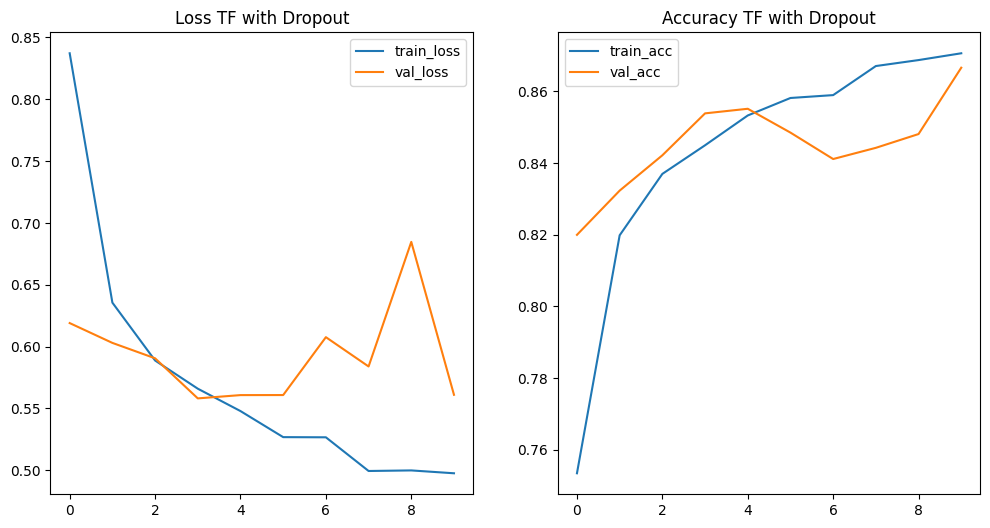

In [103]:
fig = plt.figure(figsize=(12, 6))
ax1, ax2 = fig.subplots(1, 2)
ax1.plot(range(len(train_loss_tf_dropout)), train_loss_tf_dropout, label='train_loss')
ax1.plot(range(len(val_loss_tf_dropout)), val_loss_tf_dropout, label='val_loss')
ax1.legend()
ax1.title.set_text('Loss TF with Dropout')

ax2.plot(range(len(train_acc_tf_dropout)), train_acc_tf_dropout, label='train_acc')
ax2.plot(range(len(val_acc_tf_dropout)), val_acc_tf_dropout, label='val_acc')
ax2.legend()
ax2.title.set_text('Accuracy TF with Dropout')

# Сравнение результатов

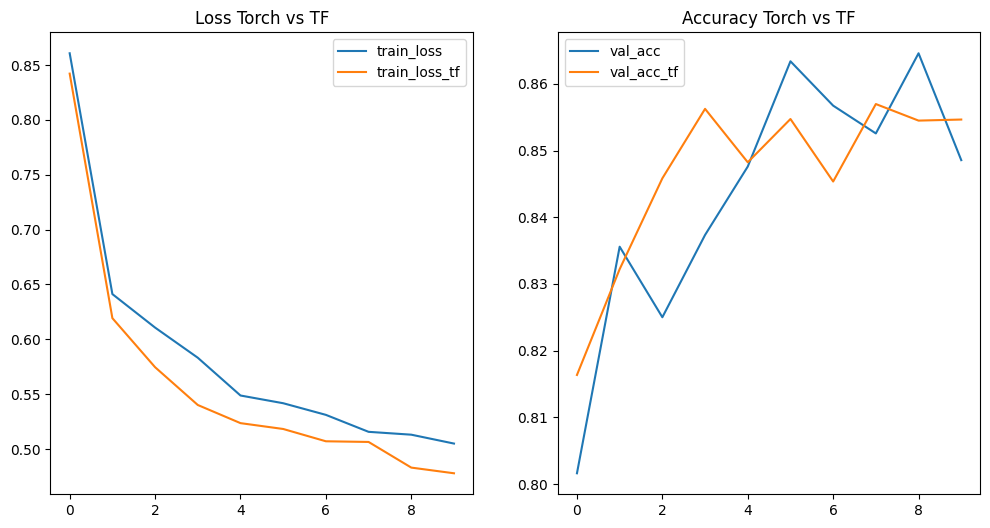

In [104]:
fig = plt.figure(figsize=(12, 6))
ax1, ax2 = fig.subplots(1, 2)
ax1.plot(range(len(train_loss)), train_loss, label='train_loss')
ax1.plot(range(len(train_loss_tf)), train_loss_tf, label='train_loss_tf')
ax1.title.set_text('Loss Torch vs TF')
ax1.legend()

ax2.plot(range(len(val_acc)), val_acc, label='val_acc')
ax2.plot(range(len(val_acc_tf)), val_acc_tf, label='val_acc_tf')
ax2.legend()
ax2.title.set_text('Accuracy Torch vs TF')

# Сравнение с baseline

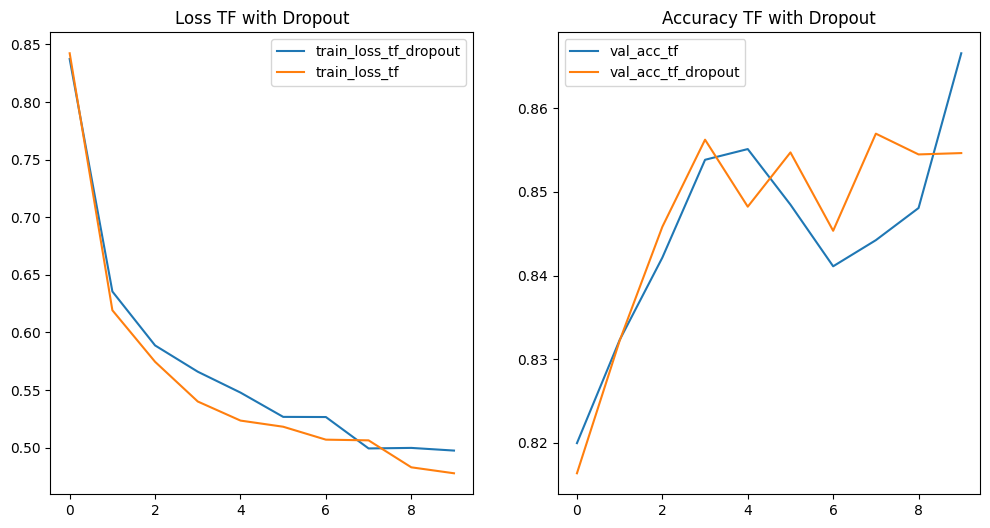

In [105]:
fig = plt.figure(figsize=(12, 6))
ax1, ax2 = fig.subplots(1, 2)
ax1.plot(range(len(train_loss_tf_dropout)), train_loss_tf_dropout, label='train_loss_tf_dropout')
ax1.plot(range(len(train_loss_tf)), train_loss_tf, label='train_loss_tf')
ax1.legend()
ax1.title.set_text('Loss TF with Dropout')

ax2.plot(range(len(val_acc_tf_dropout)), val_acc_tf_dropout, label='val_acc_tf')
ax2.plot(range(len(val_acc_tf)), val_acc_tf, label='val_acc_tf_dropout')
ax2.legend()
ax2.title.set_text('Accuracy TF with Dropout')

# Выбор лучшей модели

In [106]:
if val_acc_tf_dropout[-1] > val_acc_tf[-1]:
    print("Модель с Dropout показала лучшую точность на валидации.")
    tf_model = model_tf_dropout
else:
    print("Модель без Dropout показала лучшую точность на валидации.")
    tf_model = model_tf
    
    
if val_acc_dropout[-1] > val_acc[-1]:
    print("Модель с Dropout показала лучшую точность на валидации.")
    torch_model = model_dropout
else:
    print("Модель без Dropout показала лучшую точность на валидации.")
    torch_model = model

Модель с Dropout показала лучшую точность на валидации.
Модель без Dropout показала лучшую точность на валидации.


# Confusion matrix

In [ ]:
def get_true_labels(loader):
    labels = []
    for _, y in loader:
        labels.append(y - 1)
    return torch.cat(labels).numpy()

y_true_torch = get_true_labels(val_loader)
y_pred_tf = tf_model.predict(X_val).argmax(axis=1)
y_pred_torch = predict_val(torch_model, val_loader).numpy()

390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step


In [108]:
tf_model_cm = confusion_matrix(y_val, y_pred_tf)
torch_model_cm = confusion_matrix(y_true_torch, y_pred_torch)

Text(0.5, 1.0, 'Confusion Matrix for TensorFlow MLP')

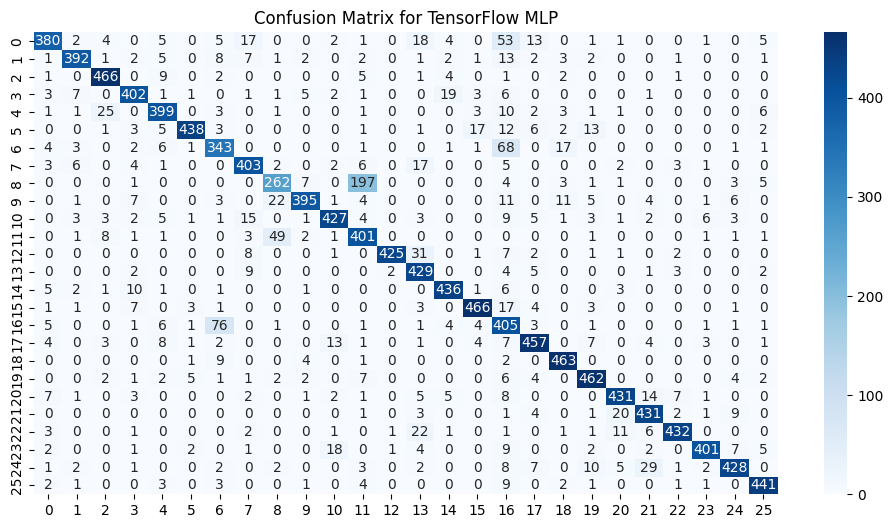

In [109]:
fig = plt.figure(figsize=(12, 6))
heatmap(tf_model_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for TensorFlow MLP')

Text(0.5, 1.0, 'Confusion Matrix for PyTorch MLP')

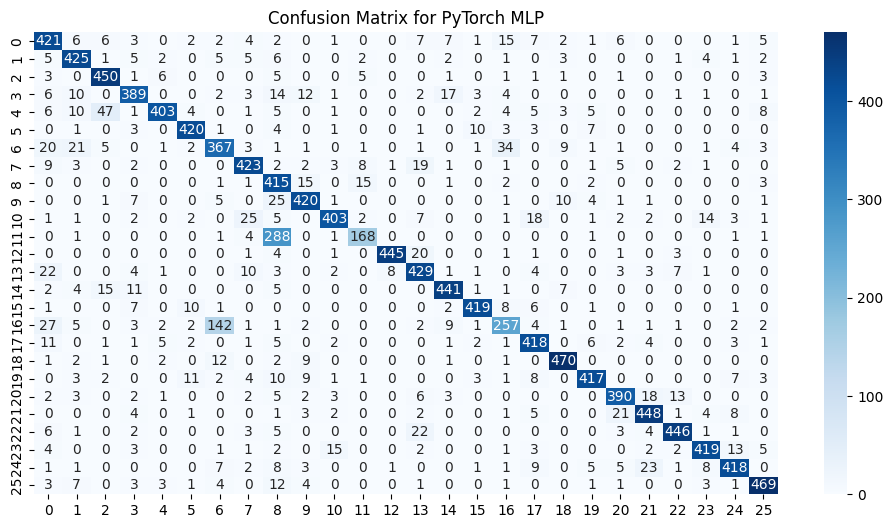

In [110]:
fig = plt.figure(figsize=(12, 6))
heatmap(torch_model_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for PyTorch MLP')

# Топ-5 пар ошибок по модели

In [111]:
def confusion_pairs(cm, label_map):
    pairs = []

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            if i != j and count > 0:  # только ошибки
                true_label = label_map[i + 1]
                pred_label = label_map[j + 1]

                pairs.append({
                    'true_label': true_label,
                    'pred_label': pred_label,
                    'count': count
                })

    return pd.DataFrame(pairs).sort_values('count', ascending=False)


tf_conf_errors = confusion_pairs(tf_model_cm, label_map)
torch_conf_errors = confusion_pairs(torch_model_cm, label_map)

print(tf_conf_errors.head(10))
print(torch_conf_errors.head(10))

    true_label pred_label  count
106          I          L    197
196          Q          G     76
88           G          Q     68
9            A          Q     53
148          L          I     49
157          M          N     31
296          Y          V     29
57           E          C     25
266          W          N     22
116          J          I     22
    true_label pred_label  count
153          L          I    288
202          Q          G    142
60           E          C     47
93           G          Q     34
197          Q          A     27
138          K          H     25
126          J          I     25
314          Y          V     23
284          W          N     22
166          N          A     22


# Визуализация примеров ошибок

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


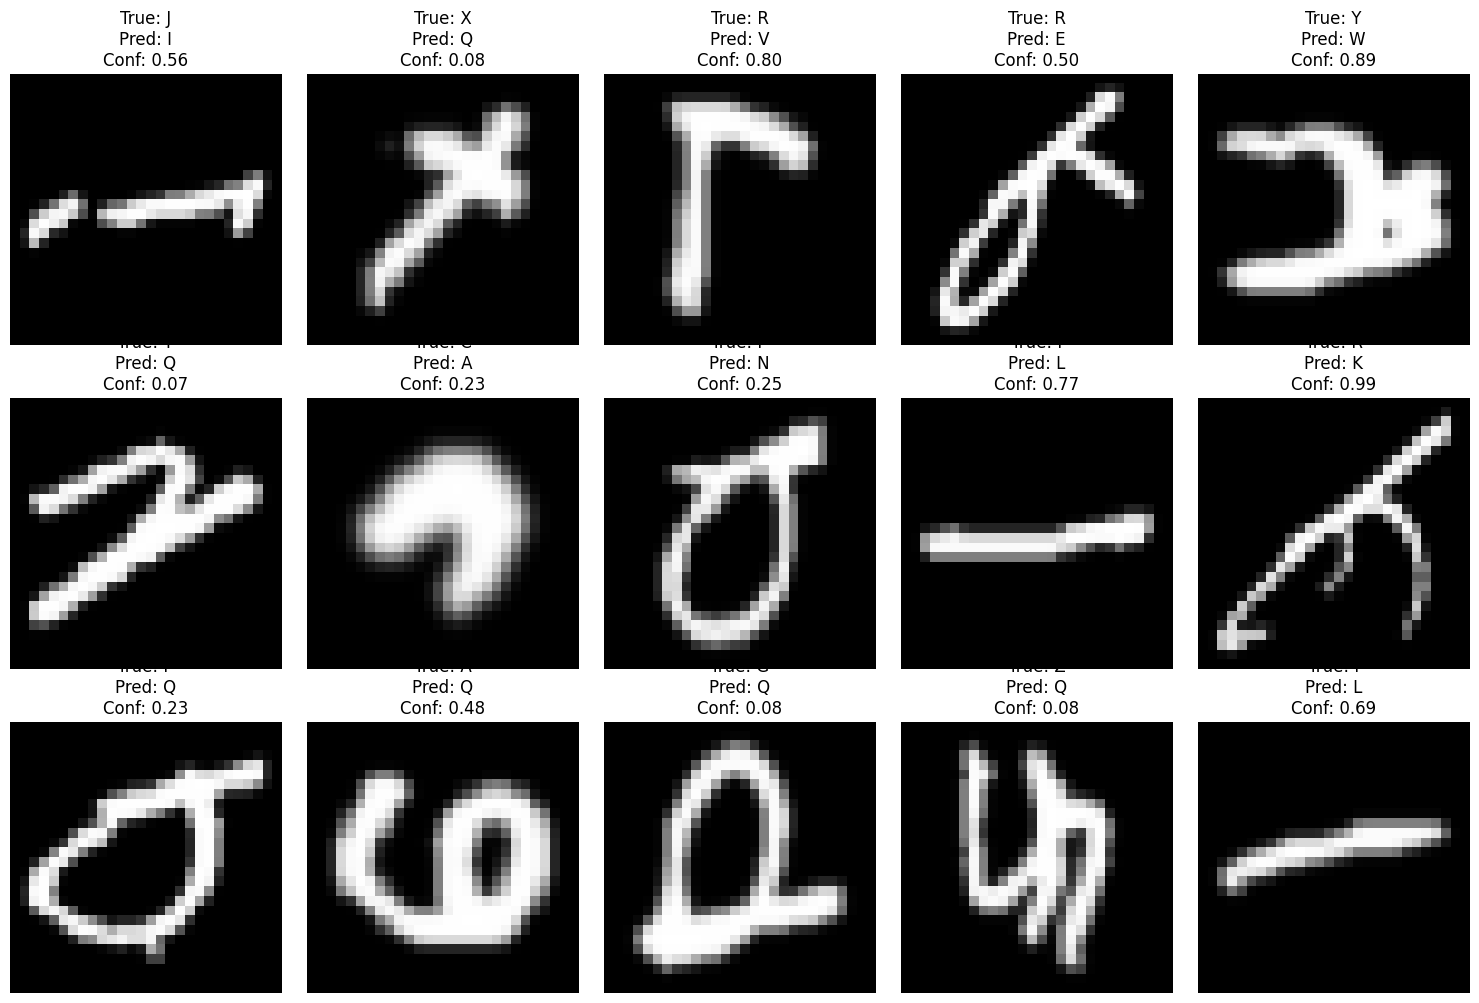

In [ ]:
false_idx_tf = []

for i, (y_pred, y_true) in enumerate(zip(y_pred_tf, y_val)):
    if len(false_idx_tf) >= 15:
        break
    if y_pred != y_true:
        false_idx_tf.append(i)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(false_idx_tf):
    plt.subplot(3, 5, i + 1)
    
    plt.imshow(X_val[idx].reshape(28, 28), cmap='gray')
    true_label = y_val[idx]
    
    predict = tf_model.predict(X_val[idx].reshape(1, 784))
    probs = tf.nn.softmax(predict)
    pred_label = y_pred_tf[idx]
    
    confidence = np.max(probs)  # вероятности модели
    plt.title(f"True: {label_map[true_label+1]}\nPred: {label_map[pred_label+1]}\nConf: {confidence:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

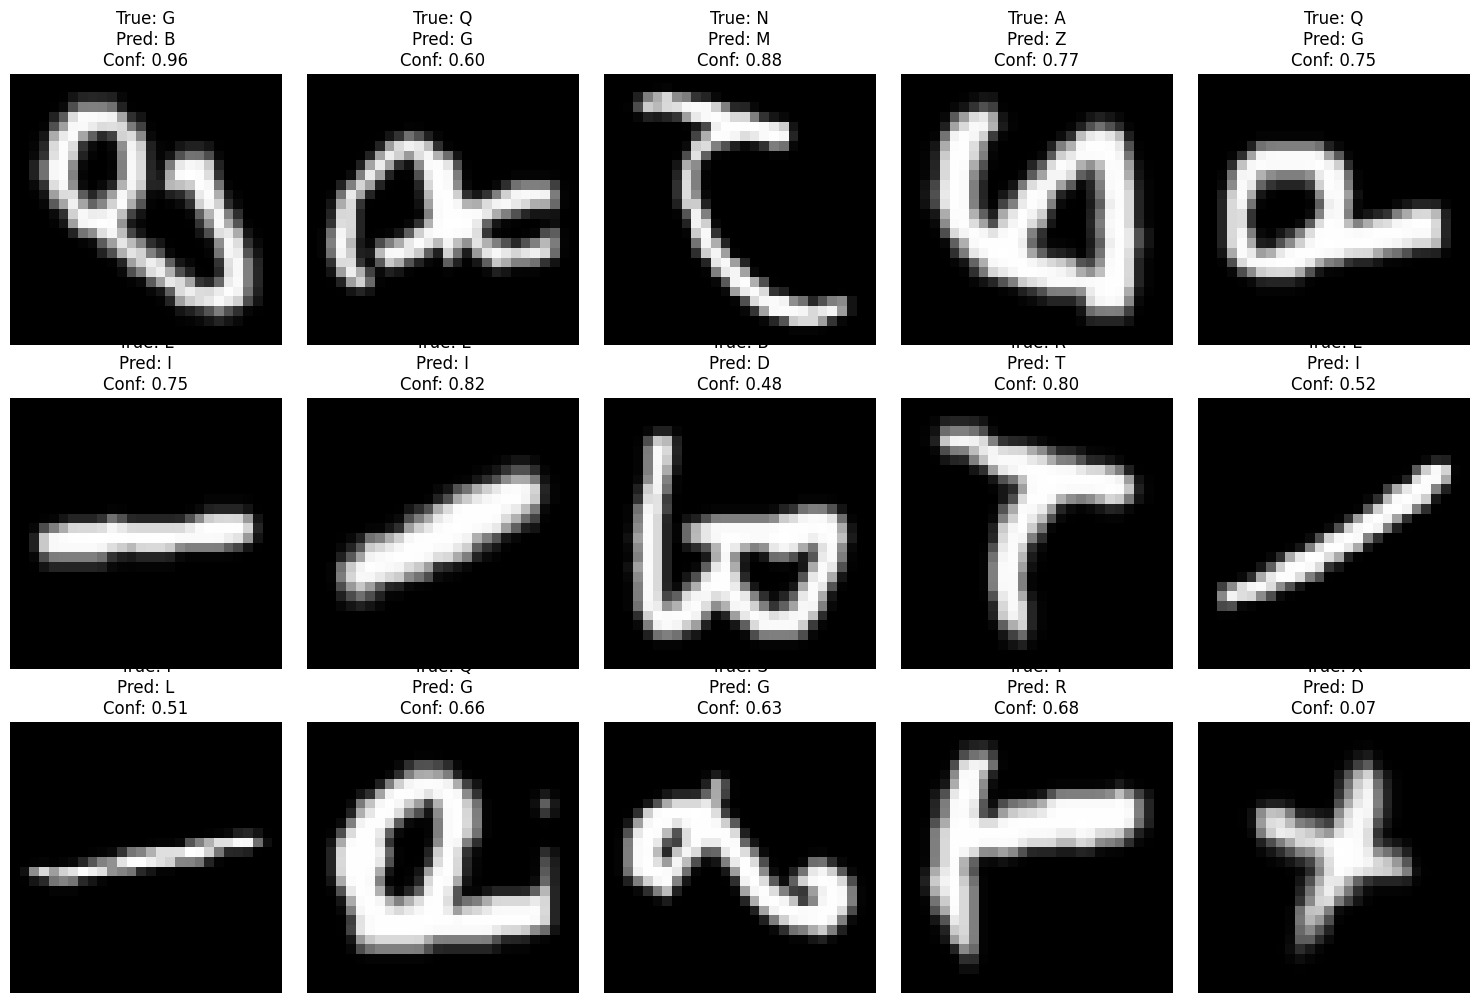

In [129]:
false_idx_tf = []

for i, (y_pred, y_true) in enumerate(zip(y_pred_torch, y_true_torch)):
    if len(false_idx_tf) >= 15:
        break
    if y_pred != y_true:
        false_idx_tf.append(i)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(false_idx_tf):
    plt.subplot(3, 5, i + 1)
    
    plt.imshow(df_val[idx][0].reshape(28, 28), cmap='gray')
    true_label = y_true_torch[idx]
    
    model.eval()
    with torch.no_grad():
        output = model(df_val[idx][0].reshape(1, 784))
        probs = F.softmax(output, dim=1)
        predicted_class = torch.argmax(probs, dim=1).item()
    
    pred_label = y_pred_torch[idx].numpy()
    
    plt.title(f"True: {label_map[true_label+1]}\nPred: {label_map[pred_label+1]}\nConf: {probs[0][predicted_class].item():.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Сравнение ошибок двух фреймворков (ДОСТАТОЧНО ПРОСТО ВЫВОДЫ НАПИСАТЬ, СРАВНЕНИЕ ВЫШЕ УЖЕ ЕСТЬ)

In [132]:
def confusion_pairs(cm, label_map):
    pairs = []

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            if i != j and count > 0:  # только ошибки
                true_label = label_map[i + 1]
                pred_label = label_map[j + 1]

                pairs.append({
                    'true_label': true_label,
                    'pred_label': pred_label,
                    'count': count
                })

    return pd.DataFrame(pairs).sort_values('count', ascending=False)


tf_conf_errors = confusion_pairs(tf_model_cm, label_map)
torch_conf_errors = confusion_pairs(torch_model_cm, label_map)

print(tf_conf_errors.head(10))
print(torch_conf_errors.head(10))

    true_label pred_label  count
106          I          L    197
196          Q          G     76
88           G          Q     68
9            A          Q     53
148          L          I     49
157          M          N     31
296          Y          V     29
57           E          C     25
266          W          N     22
116          J          I     22
    true_label pred_label  count
153          L          I    288
202          Q          G    142
60           E          C     47
93           G          Q     34
197          Q          A     27
138          K          H     25
126          J          I     25
314          Y          V     23
284          W          N     22
166          N          A     22


# Инференс и демо

tensor([[  0.6764,   1.1518,   1.8026,  -5.6410,   0.7727,   0.5607,  10.9579,
          -9.3523, -11.9890,   0.9944, -14.8995,  -1.6838,  -3.2237, -19.1153,
          -2.4590,  -4.6884,   6.1608,  -7.5655,   4.4950,  -5.4554,  -4.0588,
          -7.3050,  -5.2357, -11.6172,   4.6139,   0.3319]])


('G', 0.988228440284729)

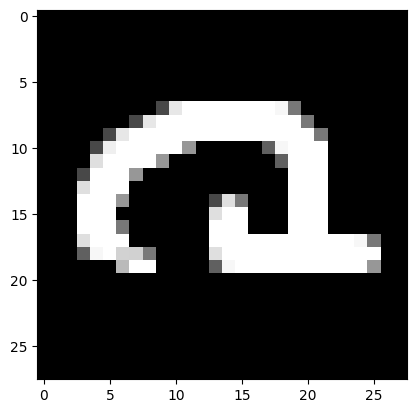

In [ ]:
def predict_letter(image_path, model, framework:str='torch'):
    image = PIL.Image.open(image_path).convert('L')
    image = image.resize((28, 28))
    image = np.array(image).T
    if image.mean() > 127:
        image = 255 - image
    image = image.astype('float32') / 255.0
    plt.imshow(image.reshape(28, 28), cmap='gray')
    image = torch.tensor(image.reshape(1, -1))
    if framework == 'torch':
        model.eval()
        with torch.no_grad():
            output = model(image)
            print(
                output.data
            )
            probs = F.softmax(output, dim=1)
            predicted_class = torch.argmax(probs, dim=1).item()
        return label_map[predicted_class + 1], probs[0][predicted_class].item()
    elif framework == 'tf':
        predict = model.predict(image)
        probs = tf.nn.softmax(predict)
        predicted_class = tf.argmax(probs, axis=1).numpy()[0]
        print(predicted_class)
        return label_map[predicted_class + 1], probs.numpy()[0][predicted_class]
    else:
        raise ValueError("Framework must be 'torch' or 'tf'")
    
    
predict_letter('./data/hand_test/G.png', torch_model, framework='torch')
